# Capítulo 1 — Introdução ao Forecasting
**Livro:** Forecasting: Principles and Practice, the Pythonic Way  
**Pesquisa:** Previsão de Demanda com Séries Hierárquicas  

---

## O que você vai aprender aqui

Este notebook cobre os conceitos fundamentais do cap. 1, mas de forma prática.  
A ideia é simples: **você executa, vê o resultado, e o conceito entra naturalmente.**

---

## Conceitos centrais do capítulo

### 1. O que é forecasting?
Previsão é estimar valores futuros com base em padrões do passado.  
Não é adivinhação — é inferência estatística sobre o futuro.

**Dois tipos de dado:**
- **Série temporal:** medições ao longo do tempo (vendas mensais, temperatura diária)
- **Cross-sectional:** medições em um ponto fixo no tempo (renda por estado num ano)

Na sua pesquisa, você vai trabalhar 100% com **séries temporais.**

---

### 2. Quando forecasting é possível?

O livro define duas condições:
1. Há dados históricos disponíveis
2. É razoável assumir que padrões do passado vão continuar

Exemplo direto da sua pesquisa: uma empresa sabe que vende determinado produto — só não sabe exatamente quando. O padrão existe. O forecasting entra justamente aqui.

---

### 3. O processo de forecasting (5 passos)

| Passo | O que fazer |
|-------|-------------|
| 1 | Definir o problema |
| 2 | Coletar os dados |
| 3 | Análise exploratória (sempre começa com gráfico) |
| 4 | Escolher e ajustar o modelo |
| 5 | Avaliar e usar o modelo |

**Regra de ouro do livro:** *"Always start by graphing the data."*  
Você vai ver isso na prática abaixo.

---

### 4. Tipos de modelo

- **Métodos simples (naïve):** usa o último valor como previsão — serve como baseline
- **Suavização exponencial (ETS):** captura tendência e sazonalidade
- **ARIMA:** modela autocorrelação da série
- **ML/DL:** modelos mais complexos, usados quando há dados suficientes
- **Hierárquicos:** previsão em múltiplos níveis — **foco da sua pesquisa**

---

## Setup

In [1]:
# instalação da lib auxiliar do livro (necessária só na primeira vez)
# !pip install fpppy utilsforecast statsforecast --quiet

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# configuração de estilo dos gráficos (padrão do livro)
plt.style.use('ggplot')
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'figure.dpi': 100,
})

print('Ambiente pronto.')

Ambiente pronto.


## Experimento 1 — Criando sua primeira série temporal

Antes de usar datasets reais, vamos criar um dado sintético simples.  
Isso remove a complexidade e deixa o conceito claro.

In [3]:
import numpy as np

# simula vendas mensais de um produto — 3 anos de histórico
np.random.seed(42)
datas = pd.date_range(start='2022-01-01', periods=36, freq='MS')  # MS = Month Start

# componentes da série
tendencia = np.linspace(100, 160, 36)          # crescimento gradual
sazonalidade = 20 * np.sin(np.linspace(0, 6 * np.pi, 36))  # padrão anual
ruido = np.random.normal(0, 8, 36)             # variação aleatória

vendas = tendencia + sazonalidade + ruido

# monta o dataframe
df = pd.DataFrame({'ds': datas, 'y': vendas})
df.head()

,ds,y
0,2022-01-01,103.973713
1,2022-02-01,110.866157
2,2022-03-01,126.221990
3,2022-04-01,137.306957
4,2022-05-01,121.675381


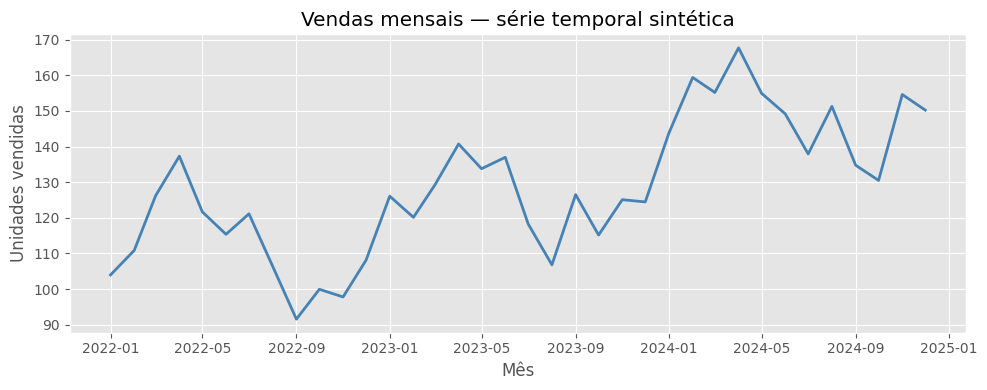

In [4]:
# REGRA DE OURO: sempre começa com gráfico
fig, ax = plt.subplots()
ax.plot(df['ds'], df['y'], color='steelblue', linewidth=2)
ax.set_title('Vendas mensais — série temporal sintética')
ax.set_xlabel('Mês')
ax.set_ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

# observe: dá pra ver tendência e sazonalidade só no gráfico
# isso é o passo 3 do processo de forecasting

## Experimento 2 — O que você enxerga no gráfico?

O livro diz: ao olhar uma série, pergunte:
- Há **tendência** (crescimento ou queda ao longo do tempo)?
- Há **sazonalidade** (padrão que se repete em períodos fixos)?
- Há **ruído** (variação aleatória sem padrão)?
- Há **outliers** (picos ou quedas anormais)?

Vamos decompor a série pra ver cada componente separado:

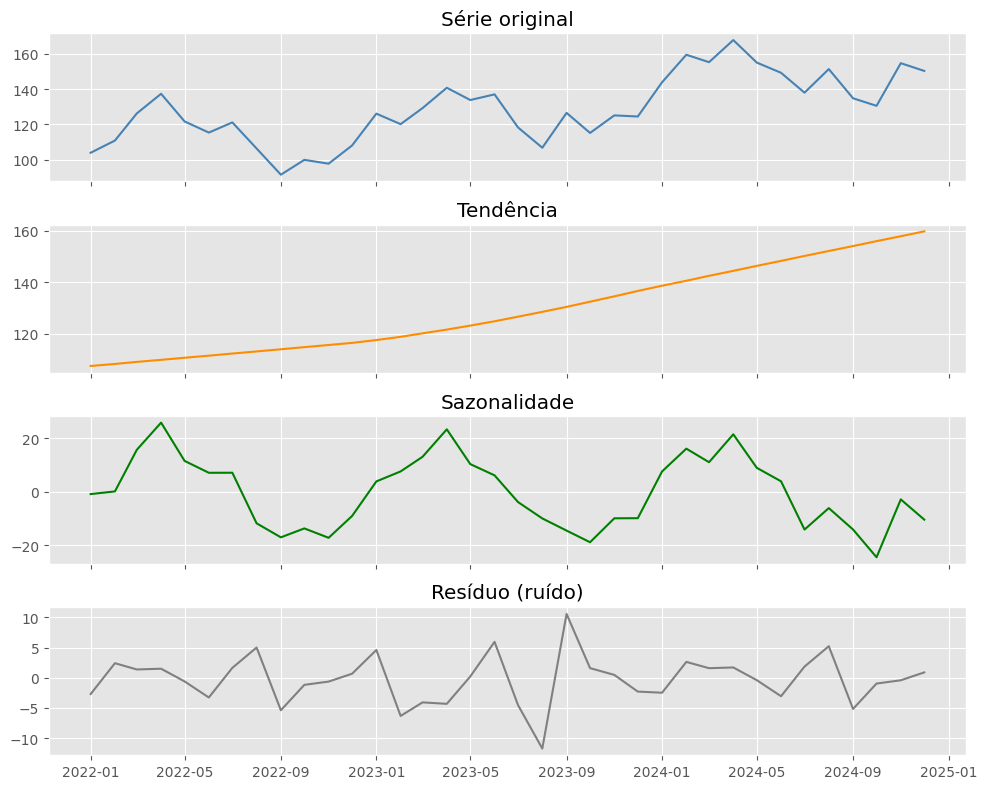

In [5]:
from statsmodels.tsa.seasonal import STL

# decomposição STL (Seasonal and Trend decomposition using Loess)
# period=12 porque são dados mensais (12 meses = 1 ciclo sazonal)
stl = STL(df['y'], period=12)
resultado = stl.fit()

# visualiza os componentes
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(df['ds'], df['y'], color='steelblue')
axes[0].set_title('Série original')

axes[1].plot(df['ds'], resultado.trend, color='darkorange')
axes[1].set_title('Tendência')

axes[2].plot(df['ds'], resultado.seasonal, color='green')
axes[2].set_title('Sazonalidade')

axes[3].plot(df['ds'], resultado.resid, color='gray')
axes[3].set_title('Resíduo (ruído)')

plt.tight_layout()
plt.show()

# isso é o que o STL faz: separa a série nos 3 componentes
# tendência + sazonalidade + resíduo = série original

## Experimento 3 — Primeira previsão real (método naïve)

O método **naïve** é o mais simples possível:  
"A previsão do próximo período é igual ao último valor observado."

Parece idiota, mas é o **baseline** — qualquer modelo decente precisa bater o naïve pra ser útil.  
Na sua pesquisa, você vai sempre comparar seus modelos hierárquicos contra esse baseline.

In [6]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive

# o nixtlaverse exige uma coluna 'unique_id' pra identificar cada série
# na sua pesquisa com séries hierárquicas, cada produto/região vira um unique_id
df_sf = df.copy()
df_sf['unique_id'] = 'produto_A'
df_sf = df_sf[['unique_id', 'ds', 'y']]  # ordem obrigatória

# configura o StatsForecast com dois modelos
sf = StatsForecast(
    models=[
        Naive(),          # último valor = previsão
        SeasonalNaive(season_length=12),  # último mesmo mês do ano = previsão
    ],
    freq='MS',  # frequência mensal
)

# gera previsão pra 6 meses à frente
previsao = sf.forecast(df=df_sf, h=6)
previsao

,unique_id,ds,Naive,SeasonalNaive
0,produto_A,2025-01-01,150.233251,143.815292
1,produto_A,2025-02-01,150.233251,159.381153
2,produto_A,2025-03-01,150.233251,155.182475
3,produto_A,2025-04-01,150.233251,167.681854
4,produto_A,2025-05-01,150.233251,154.950596
5,produto_A,2025-06-01,150.233251,149.173522


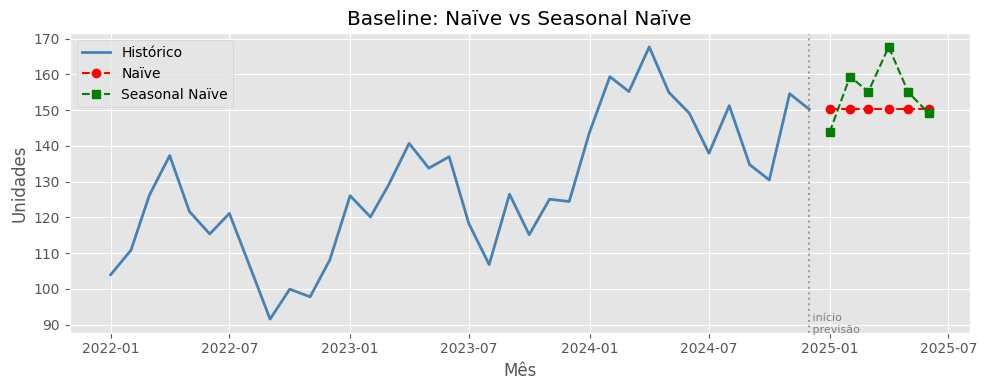

In [7]:
# visualiza histórico + previsão
fig, ax = plt.subplots()

# histórico
ax.plot(df['ds'], df['y'], label='Histórico', color='steelblue', linewidth=2)

# previsões
ax.plot(previsao['ds'], previsao['Naive'], label='Naïve', 
        color='red', linestyle='--', marker='o')
ax.plot(previsao['ds'], previsao['SeasonalNaive'], label='Seasonal Naïve', 
        color='green', linestyle='--', marker='s')

# linha vertical separando histórico de previsão
ax.axvline(x=df['ds'].iloc[-1], color='gray', linestyle=':', alpha=0.7)
ax.text(df['ds'].iloc[-1], ax.get_ylim()[0], ' início\n previsão', 
        fontsize=8, color='gray')

ax.set_title('Baseline: Naïve vs Seasonal Naïve')
ax.set_xlabel('Mês')
ax.set_ylabel('Unidades')
ax.legend()
plt.tight_layout()
plt.show()

# o Seasonal Naïve já é bem melhor que o Naïve simples pra dados com sazonalidade
# qualquer modelo que você desenvolver na pesquisa precisa bater esses dois

## Experimento 4 — Dataset real do livro

O livro usa um dataset de turismo australiano.  
É o mesmo dataset do **capítulo 11 (hierárquico)** — já vai aparecer lá de novo.  
Por isso faz sentido conhecer agora.

In [11]:
# carrega dataset real do livro (já no formato nixtlaverse)
turismo = pd.read_csv('data/aus_tourism.csv', parse_dates=['ds'])

print(f'Shape: {turismo.shape}')
print(f'Séries únicas: {turismo["unique_id"].nunique()}')
print(f'Período: {turismo["ds"].min()} a {turismo["ds"].max()}')
turismo.head(10)

Shape: (24320, 3)
Séries únicas: 304
Período: 1998-03-31 00:00:00 a 2017-12-31 00:00:00


,unique_id,ds,y
0,Adelaide-South Australia-Business,1998-03-31,135.077690
1,Adelaide-South Australia-Business,1998-06-30,109.987316
2,Adelaide-South Australia-Business,1998-09-30,166.034687
3,Adelaide-South Australia-Business,1998-12-31,127.160464
4,Adelaide-South Australia-Business,1999-03-31,137.448533
5,Adelaide-South Australia-Business,1999-06-30,199.912586
6,Adelaide-South Australia-Business,1999-09-30,169.355090
7,Adelaide-South Australia-Business,1999-12-31,134.357937
8,Adelaide-South Australia-Business,2000-03-31,154.034398
9,Adelaide-South Australia-Business,2000-06-30,168.776364


In [13]:
# estrutura hierárquica — o unique_id codifica tudo junto
# formato: Região-Estado-Propósito
print(turismo['unique_id'].head(10))
print()

# separa os componentes
turismo[['Region', 'State', 'Purpose']] = turismo['unique_id'].str.rsplit('-', n=2, expand=True)

print('Estados únicos:', turismo['State'].nunique())
print('Regiões únicas:', turismo['Region'].nunique())
print('Propósitos:', turismo['Purpose'].unique())
print(f'Total de séries: {turismo["unique_id"].nunique()}')

0    Adelaide-South Australia-Business
1    Adelaide-South Australia-Business
2    Adelaide-South Australia-Business
3    Adelaide-South Australia-Business
4    Adelaide-South Australia-Business
5    Adelaide-South Australia-Business
6    Adelaide-South Australia-Business
7    Adelaide-South Australia-Business
8    Adelaide-South Australia-Business
9    Adelaide-South Australia-Business
Name: unique_id, dtype: object

Estados únicos: 8
Regiões únicas: 76
Propósitos: ['Business' 'Holiday' 'Other' 'Visiting']
Total de séries: 304


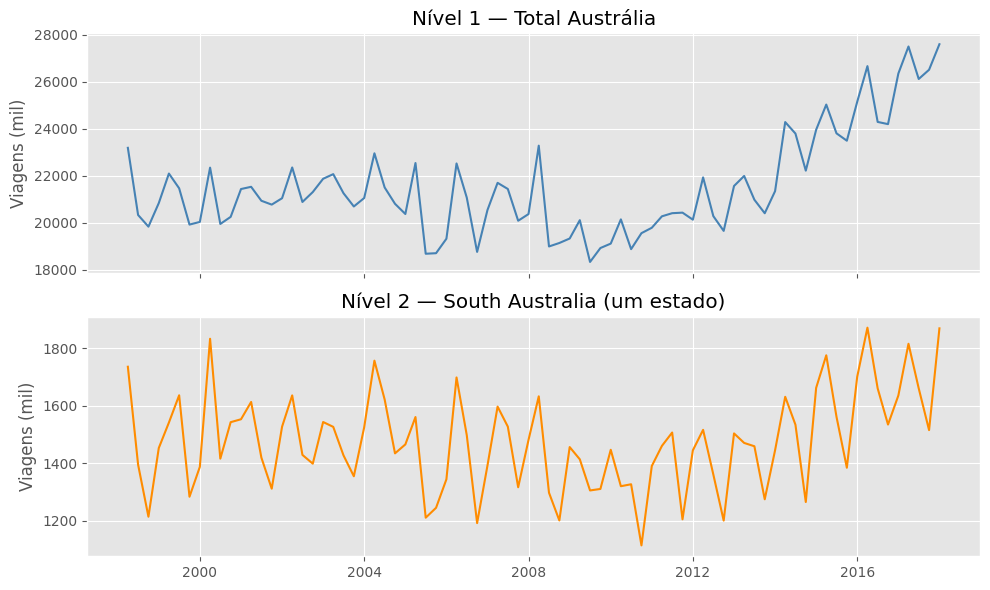

In [15]:
# visualiza algumas séries — já percebe a ideia de hierarquia
# total do país vs um estado específico
total_australia = turismo.groupby('ds')['y'].sum().reset_index()
nsw = turismo[turismo['State'] == 'South Australia'].groupby('ds')['y'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(total_australia['ds'], total_australia['y'], color='steelblue')
axes[0].set_title('Nível 1 — Total Austrália')
axes[0].set_ylabel('Viagens (mil)')

axes[1].plot(nsw['ds'], nsw['y'], color='darkorange')
axes[1].set_title('Nível 2 — South Australia (um estado)')
axes[1].set_ylabel('Viagens (mil)')

plt.tight_layout()
plt.show()

## Consolidando — O que você precisa saber do cap. 1

| Conceito | Aplicação na sua pesquisa |
|----------|---------------------------|
| Série temporal | Cada produto/região com histórico de vendas |
| Tendência + sazonalidade + ruído | Componentes que seu modelo vai capturar |
| Baseline naïve | Ponto de comparação obrigatório nos experimentos |
| Estrutura hierárquica | Produto → Categoria → Loja → Total |
| `unique_id` no nixtlaverse | Identificador de cada série no pipeline |

---

## Próximo passo

**Cap. 2 — Time Series Graphics**  
Você vai aprender a enxergar padrões em séries temporais visualmente:  
autocorrelação, sazonalidade, tendência — as ferramentas de diagnóstico que todo pesquisador usa antes de modelar.

---
*Notebook gerado como material de estudo para pesquisa de mestrado — Previsão de Demanda com Séries Hierárquicas*